# Comparación de longitudes de full text
Analiza la evolución del contenido entre los pasos 4 (raw) y 5 (texto limpio) con un enfoque accionable similar al notebook de API Performance: cobertura, retención por cliente/formato y variación de longitud.

In [643]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from models.paper import Paper
from utils.intermediate_io import STEP4_FILE, STEP5_FILE, STEP6_FILE, load_model_list

In [644]:
papers4 = load_model_list(STEP4_FILE, Paper)
papers5 = load_model_list(STEP5_FILE, Paper)
papers6 = load_model_list(STEP6_FILE, Paper)

print(f"Step4: {len(papers4)} papers | Step5: {len(papers5)} papers | Step6: {len(papers6)} papers")

Step4: 52 papers | Step5: 52 papers | Step6: 49 papers


In [645]:
def paper_id(p: Paper) -> str:
    return (p.doi or p.title).strip().lower()

def row_from_paper(p: Paper, step: int):
    if not p.full_text:
        return None
    return {
        "paper_id": paper_id(p),
        f"step{step}_format": p.full_text.format.value,
        f"step{step}_len": len(p.full_text.content),
        f"step{step}_client": p.ft_retrieved_by or "unknown",
    }

rows4 = [r for p in papers4 if (r := row_from_paper(p, 4))]
rows5 = [r for p in papers5 if (r := row_from_paper(p, 5))]

df4 = pd.DataFrame(rows4).set_index("paper_id")
df5 = pd.DataFrame(rows5).set_index("paper_id")

merged = df4.join(df5, how="outer").reset_index()

long_parts = []
for step in (4, 5):
    subset = merged[["paper_id", f"step{step}_len", f"step{step}_format", f"step{step}_client"]].dropna(subset=[f"step{step}_len"]).copy()
    subset.rename(columns={
        f"step{step}_len": "length",
        f"step{step}_format": "format",
        f"step{step}_client": "client",
    }, inplace=True)
    subset["step"] = step
    long_parts.append(subset)

lengths_long = pd.concat(long_parts, ignore_index=True)
merged.head()

# list all papers ordered by step4 length, showing step4 and step5 lengths, clients and formats
merged.sort_values(by="step5_len", ascending=False)[["paper_id", "step4_len", "step4_format", "step4_client", "step5_len", "step5_format", "step5_client"]].head(100)

,paper_id,step4_len,step4_format,step4_client,step5_len,step5_format,step5_client
14,10.1016/j.micpath.2025.107691,235090,plain,elsevier,230047,plain,elsevier
51,10.7554/elife.84669,266982,xml,europe_pmc,133342,xml,europe_pmc
7,10.1016/j.bbrc.2025.151358,125824,plain,elsevier,124264,plain,elsevier
34,10.1107/s2053230x13033141,265277,html,unpaywall,120328,html,unpaywall
28,10.1038/s44259-025-00131-1,238637,xml,europe_pmc,114854,xml,europe_pmc
11,10.1016/j.jmb.2019.06.019,107723,plain,elsevier,106036,plain,elsevier
38,10.1128/mbio.02337-25,229557,xml,europe_pmc,102259,xml,europe_pmc
12,10.1016/j.jmgm.2022.108262,104023,plain,elsevier,102218,plain,elsevier
23,10.1038/s41467-025-58202-w,207933,xml,europe_pmc,102063,xml,europe_pmc
13,10.1016/j.jphotochem.2026.117208,101579,plain,elsevier,100372,plain,elsevier


In [646]:
summary = (
    merged.dropna(subset=["step4_format", "step4_len"])
    .groupby("step4_format")
    .agg(
        n_step4=("step4_len", "count"),
        mean_len_step4=("step4_len", "mean"),
        median_len_step4=("step4_len", "median"),
        n_step5=("step5_len", "count"),
        mean_len_step5=("step5_len", "mean"),
        median_len_step5=("step5_len", "median"),
    )
    .assign(pct_with_step5=lambda df: df["n_step5"] / df["n_step4"] * 100)
    .sort_values("n_step4", ascending=False)
)
summary

,n_step4,mean_len_step4,median_len_step4,n_step5,mean_len_step5,median_len_step5,pct_with_step5
step4_format,,,,,,,
xml,26,1.687688e+05,163540.0,26,72268.538462,73017.5,100.0
plain,12,9.488067e+04,101442.5,12,93299.833333,100113.0,100.0
pdf,7,3.014403e+06,1300204.0,7,59278.142857,72397.0,100.0
html,7,1.903273e+05,202975.0,7,46843.857143,51441.0,100.0


## Distribuciones y relaciones
Visualizaciones básicas para ver cómo cambian las longitudes por formato entre los pasos 4 (raw) y 5 (texto limpio).

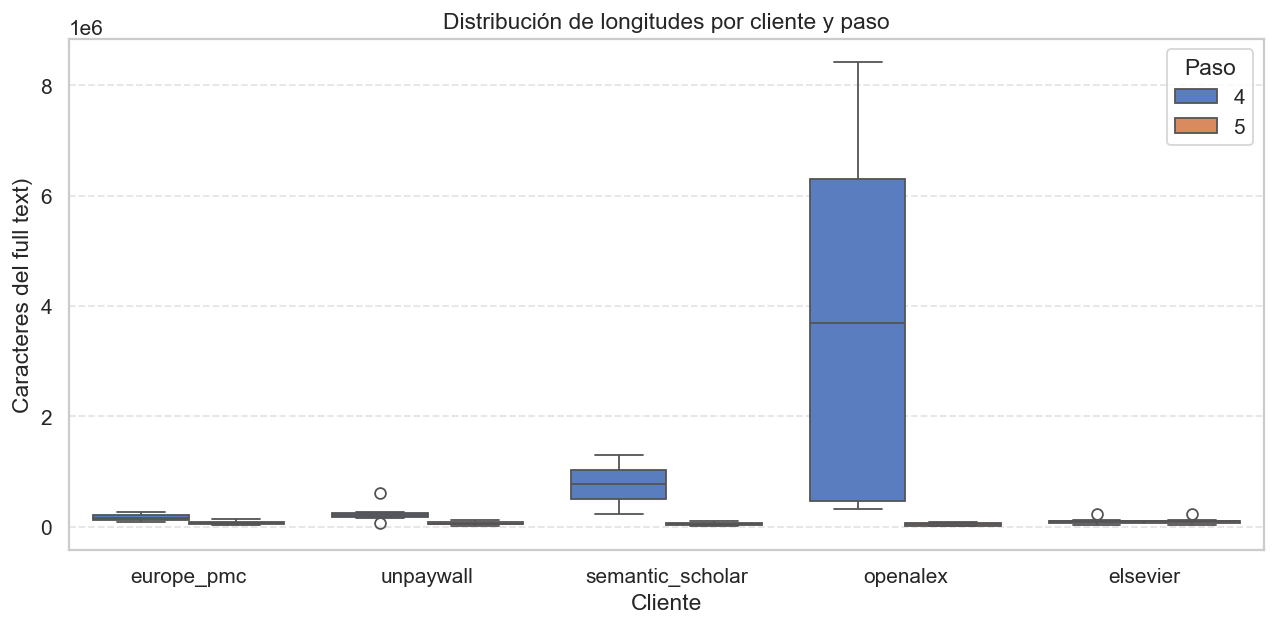

In [647]:
fig, ax = plt.subplots(figsize=(10, 5))

# subplot 1: boxplot
sns.boxplot(
    data=lengths_long,
    x="client",
    y="length",
    hue="step",
    palette="muted",
    ax=ax
)

ax.set_title("Distribución de longitudes por cliente y paso")
ax.set_xlabel("Cliente")
ax.set_ylabel("Caracteres del full text)")
ax.legend(title="Paso")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()


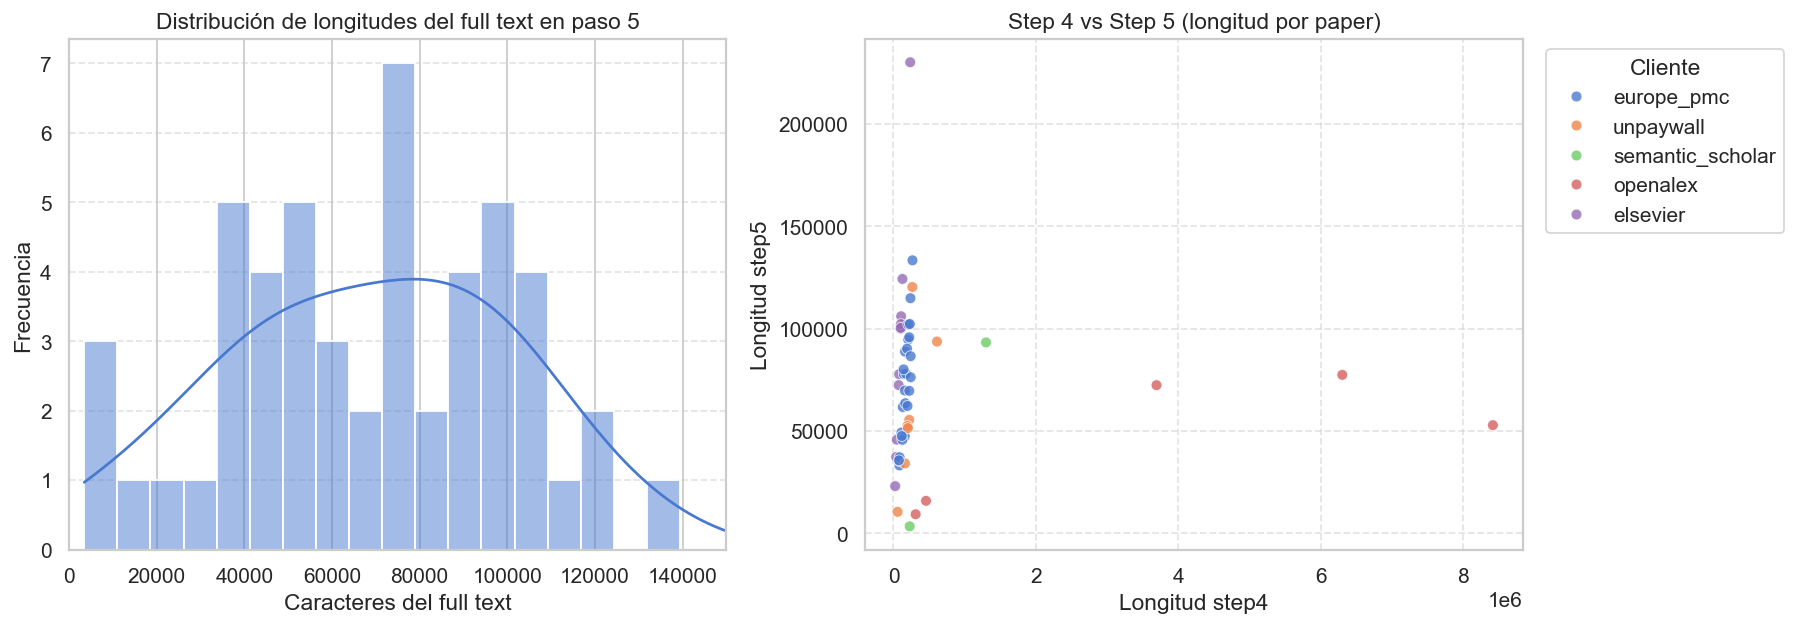

In [648]:
# Mostrar ambos plots en la misma celda (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Histograma de longitudes en step 5
sns.histplot(
    data=merged.dropna(subset=["step5_len"]),
    x="step5_len",
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribución de longitudes del full text en paso 5")
# limitar el eje x a 150000
axes[0].set_xlim(0, 150000)
axes[0].set_xlabel("Caracteres del full text")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

# 2) Scatter step4 vs step5 (papers presentes en ambos pasos)
sns.scatterplot(
    data=both,
    x="step4_len",
    y="step5_len",
    hue="step5_client",
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Step 4 vs Step 5 (longitud por paper)")
axes[1].set_xlabel("Longitud step4")
axes[1].set_ylabel("Longitud step5")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(title="Cliente", bbox_to_anchor=(1.02, 1), loc="upper left")


plt.tight_layout()

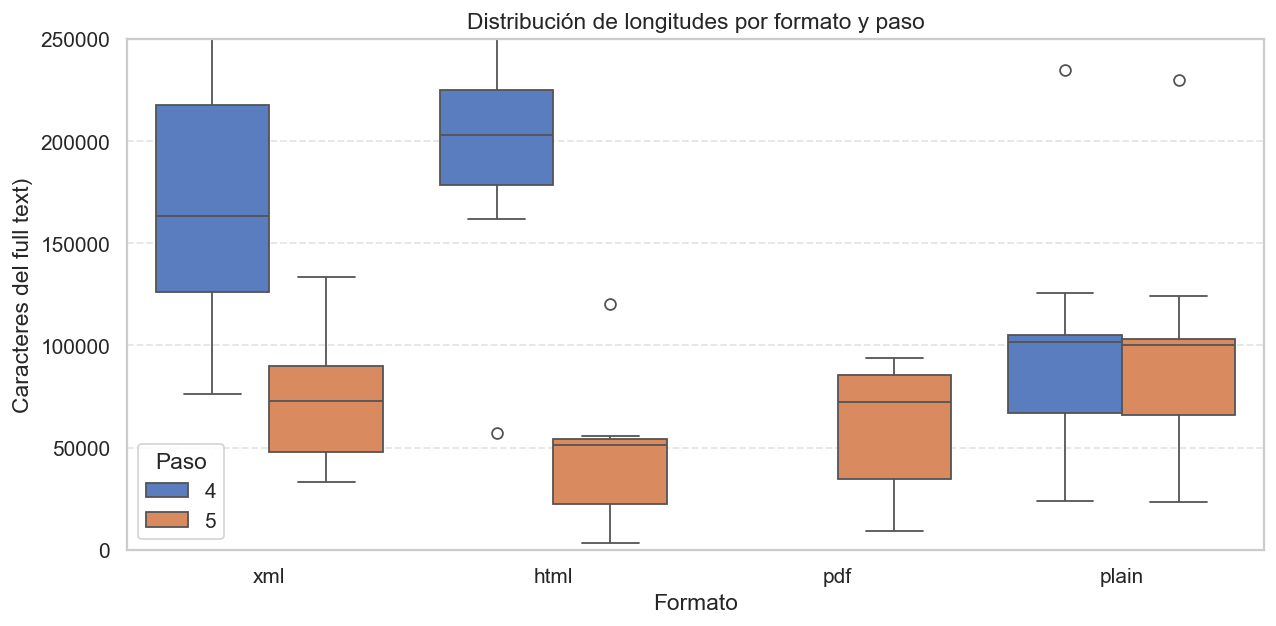

In [649]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=lengths_long,
    x="format",
    y="length",
    hue="step",
    palette="muted",
    ax=ax
)

ax.set_title("Distribución de longitudes por formato y paso")
ax.set_xlabel("Formato")
ax.set_ylabel("Caracteres del full text)")
ax.legend(title="Paso")
# set y axes btween 0 and 250k
ax.set_ylim(0, 250_000)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

In [650]:
both = merged.dropna(subset=["step4_len", "step5_len"]).copy()
both["delta_len"] = both["step5_len"] - both["step4_len"]
both["pct_delta"] = both["delta_len"] / both["step4_len"] * 100
delta_stats = {
    "count": len(both),
    "median_delta": both["delta_len"].median(),
    "mean_delta": both["delta_len"].mean(),
    "median_pct_delta": both["pct_delta"].median(),
    "mean_pct_delta": both["pct_delta"].mean(),
}
delta_stats

{'count': 52,
 'median_delta': np.float64(-99956.5),
 'mean_delta': np.float64(-465735.3653846154),
 'median_pct_delta': np.float64(-56.15907547012914),
 'mean_pct_delta': np.float64(-52.00724353673441)}

## Análisis por cliente de full text
Cuantifica cobertura y tamaño de los textos según el cliente que devolvió el full text (ft_retrieved_by).

In [651]:
client_overview = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["step", "client"], dropna=False)
    .agg(
        n=("length", "count"),
        mean_len=("length", "mean"),
        median_len=("length", "median"),
    )
    .sort_values(["step", "n"], ascending=False)
    .reset_index()
)
client_overview.head(20)

,step,client,n,mean_len,median_len
0,5,europe_pmc,26,7.226854e+04,73017.5
1,5,elsevier,12,9.329983e+04,100113.0
2,5,unpaywall,7,5.973257e+04,52462.0
3,5,openalex,5,4.559780e+04,52866.0
4,5,semantic_scholar,2,4.836850e+04,48368.5
5,4,europe_pmc,26,1.687688e+05,163540.0
6,4,elsevier,12,9.488067e+04,101442.5
7,4,unpaywall,7,2.450797e+05,202975.0
8,4,openalex,5,3.837874e+06,3695016.0
9,4,semantic_scholar,2,7.640925e+05,764092.5


In [652]:
client_format = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["step", "client", "format"], dropna=False)
    .agg(
        n=("length", "count"),
        mean_len=("length", "mean"),
        median_len=("length", "median"),
    )
    .sort_values(["step", "client", "n"], ascending=False)
    .reset_index()
)
client_format.head(20)

,step,client,format,n,mean_len,median_len
0,5,unpaywall,html,6,5.407217e+04,51951.5
1,5,unpaywall,pdf,1,9.369500e+04,93695.0
2,5,semantic_scholar,html,1,3.474000e+03,3474.0
3,5,semantic_scholar,pdf,1,9.326300e+04,93263.0
4,5,openalex,pdf,5,4.559780e+04,52866.0
5,5,europe_pmc,xml,26,7.226854e+04,73017.5
6,5,elsevier,plain,12,9.329983e+04,100113.0
7,4,unpaywall,html,6,1.840517e+05,199124.0
8,4,unpaywall,pdf,1,6.112480e+05,611248.0
9,4,semantic_scholar,html,1,2.279810e+05,227981.0


## Caracteres antes y después por cliente y formato
Barras agrupadas con el número total de caracteres de full text antes (paso 4) y después (paso 5) de la extracción, desglosado por cliente y por formato.

,client,step,total_chars,n,avg_chars
0,elsevier,4,1138568,12,9.488067e+04
1,elsevier,5,1119598,12,9.329983e+04
2,europe_pmc,4,4387990,26,1.687688e+05
3,europe_pmc,5,1878982,26,7.226854e+04
4,openalex,4,19189372,5,3.837874e+06
5,openalex,5,227989,5,4.559780e+04
6,semantic_scholar,4,1528185,2,7.640925e+05
7,semantic_scholar,5,96737,2,4.836850e+04
8,unpaywall,4,1715558,7,2.450797e+05
9,unpaywall,5,418128,7,5.973257e+04


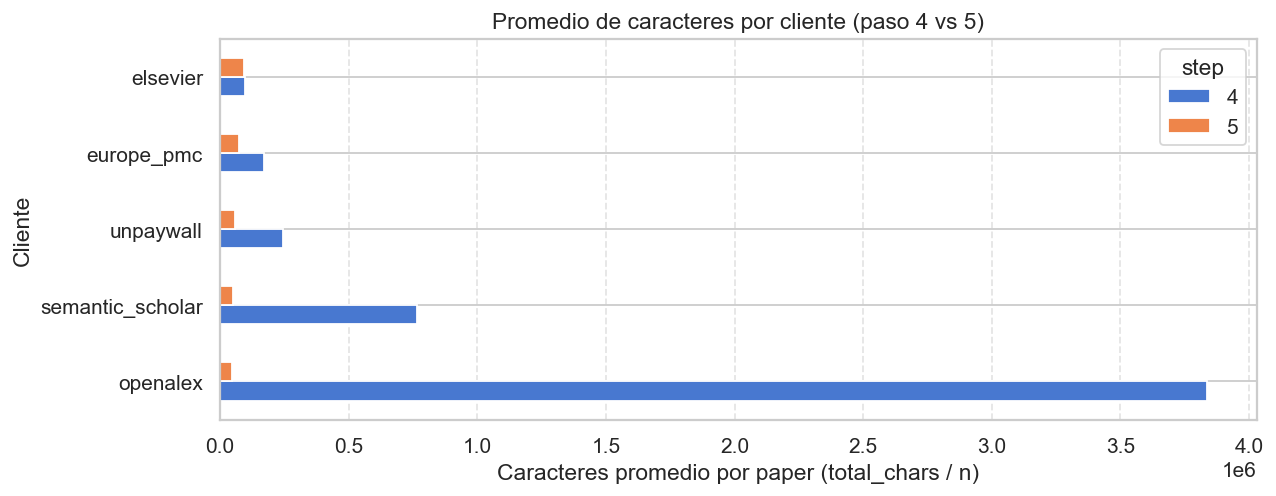

In [653]:
client_chars = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["client", "step"], dropna=False)
    .agg(total_chars=("length", "sum"), n=("paper_id", "count"))
    .reset_index()
)
client_chars["avg_chars"] = client_chars["total_chars"] / client_chars["n"]

client_chars_pivot = (
    client_chars.pivot(index="client", columns="step", values="avg_chars")
    .fillna(0)
    .sort_values(by=4, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(client_chars_pivot) * 0.3)))
client_chars_pivot[[4, 5]].plot(kind="barh", ax=ax)
ax.set_title("Promedio de caracteres por cliente (paso 4 vs 5)")
ax.set_xlabel("Caracteres promedio por paper (total_chars / n)")
ax.set_ylabel("Cliente")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

client_chars.head(10)

,format,step,total_chars,n,avg_chars
0,html,4,1332291,7,1.903273e+05
1,html,5,327907,7,4.684386e+04
2,pdf,4,21100824,7,3.014403e+06
3,pdf,5,414947,7,5.927814e+04
4,plain,4,1138568,12,9.488067e+04
5,plain,5,1119598,12,9.329983e+04
6,xml,4,4387990,26,1.687688e+05
7,xml,5,1878982,26,7.226854e+04


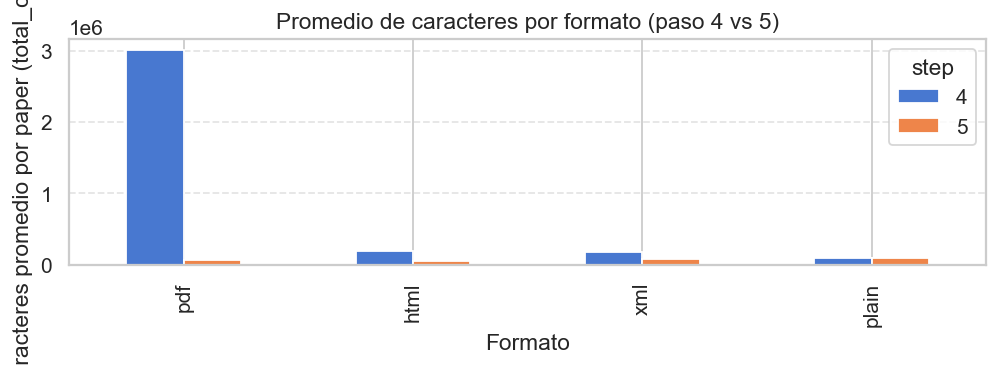

In [654]:
format_chars = (
    lengths_long.groupby(["format", "step"])
    .agg(total_chars=("length", "sum"), n=("paper_id", "count"))
    .reset_index()
 )

format_chars["avg_chars"] = format_chars["total_chars"] / format_chars["n"]

format_chars_pivot = (
    format_chars.pivot(index="format", columns="step", values="avg_chars")
    .fillna(0)
    .sort_values(by=4, ascending=False)
 )

fig, ax = plt.subplots(figsize=(8, max(3, len(format_chars_pivot) * 0.6)))
format_chars_pivot[[4, 5]].plot(kind="bar", ax=ax)
ax.set_title("Promedio de caracteres por formato (paso 4 vs 5)")
ax.set_ylabel("Caracteres promedio por paper (total_chars / n)")
ax.set_xlabel("Formato")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
format_chars

## Panel de métricas clave
Cobertura de extracción, variación de longitud y pérdidas por cliente/formato.

In [655]:
kpi = {
    "Cobertura step5 vs step4 (%)": round(df5.shape[0] / df4.shape[0] * 100, 2) if len(df4) else np.nan,
    "Mediana variación %": round(both["pct_delta"].median(), 2),
    "Media variación %": round(both["pct_delta"].mean(), 2),
    "Papers que pierden >20%": round((both["pct_delta"] < -20).mean() * 100, 2),
    "Papers que crecen >20%": round((both["pct_delta"] > 20).mean() * 100, 2),
}
pd.DataFrame.from_dict(kpi, orient="index", columns=["valor"])

,valor
Cobertura step5 vs step4 (%),100.00
Mediana variación %,-56.16
Media variación %,-52.01
Papers que pierden >20%,76.92
Papers que crecen >20%,0.00


## Retención por cliente
Cobertura de cada cliente de full text: cuántos textos llegan a paso 5 respecto a los disponibles en paso 4 (se muestran solo clientes con ≥5 textos en paso 4).

C:\Users\rebec\AppData\Local\Temp\ipykernel_11628\1213471325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retencion_cliente.reset_index(), y="step4_client", x="pct_step5", palette="crest", ax=ax)


,step4_client,n_step4,n_step5,pct_step5
0,elsevier,12,12,100.0
1,europe_pmc,26,26,100.0
2,openalex,5,5,100.0
3,unpaywall,7,7,100.0


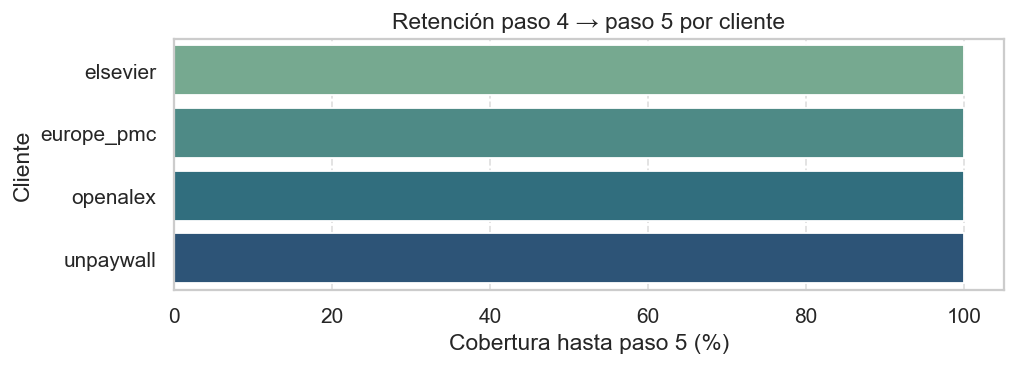

In [656]:
retencion_cliente = (
    merged[merged["step4_len"].notna()]
    .groupby("step4_client")
    .agg(n_step4=("step4_len", "count"), n_step5=("step5_len", "count"))
)
retencion_cliente["pct_step5"] = retencion_cliente["n_step5"] / retencion_cliente["n_step4"] * 100
retencion_cliente = retencion_cliente[retencion_cliente["n_step4"] >= 5].sort_values("pct_step5")

fig, ax = plt.subplots(figsize=(8, max(3, len(retencion_cliente) * 0.35)))
sns.barplot(data=retencion_cliente.reset_index(), y="step4_client", x="pct_step5", palette="crest", ax=ax)
ax.set_xlabel("Cobertura hasta paso 5 (%)")
ax.set_ylabel("Cliente")
ax.set_title("Retención paso 4 → paso 5 por cliente")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
retencion_cliente.reset_index().head(10)